# Lab Assignment 1: Data Scraping and Preprocessing
**Course**: DS605  
**Student Name**: Priyanshu  
**Student ID**: 202618046  

---
## Objective
Build a complete data pipeline by scraping book information from `https://books.toscrape.com/`, preprocessing and cleaning the dataset, performing feature engineering, creating data visualizations, and setting up an analysis framework.

## Environment Setup
We will first verify that all necessary packages are installed. If you run this notebook and encounter missing dependencies, you can uncomment and run the cell below to install them.

In [ ]:
# !pip install scrapy crochet pandas matplotlib seaborn wordcloud

## Task 1 - Data Scraping
In this section, we define the Scrapy spider and execute it directly inside this notebook. 
To run Scrapy in-memory within an interactive Jupyter session without encountering Twisted reactor errors (e.g. `ReactorNotRestartable`), we use the `crochet` library to manage the reactor in a background thread.

The crawled data will be saved directly in the current working directory as `books_raw.csv`.

In [2]:
import scrapy
from scrapy.crawler import CrawlerRunner
from crochet import setup, wait_for
import os
import pandas as pd

# 1. Initialize Crochet. This starts the Twisted reactor in a background thread.
# subsequent runs of this cell will reuse the active reactor safely.
setup()

# 2. Define the Scrapy Spider
class BookSpider(scrapy.Spider):
    name = "book_spider"
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]
    
    page_count = 1
    max_pages = 6  # Crawling 6 pages to ensure we get 120 books (> 100 limit)

    def parse(self, response):
        # Extract book links from catalog page and follow them
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()
        for link in book_links:
            yield response.follow(link, self.parse_book_details)
            
        # Follow pagination
        self.page_count += 1
        if self.page_count <= self.max_pages:
            next_page = response.css("li.next a::attr(href)").get()
            if next_page:
                yield response.follow(next_page, self.parse)

    def parse_book_details(self, response):
        def get_table_value(header_text):
            xpath_query = f"//table[contains(@class, 'table-striped')]/tr[th[contains(text(), '{header_text}')]]/td/text()"
            return response.xpath(xpath_query).get()

        rating_class = response.css("p.star-rating::attr(class)").get()
        rating = rating_class.replace("star-rating", "").strip() if rating_class else None
        description = response.css("#product_description + p::text").get()

        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": response.xpath("//ul[@class='breadcrumb']/li[3]/a/text()").get(),
            "price": response.css("p.price_color::text").get(),
            "rating": rating,
            "availability": get_table_value("Availability"),
            "product_description": description,
            "UPC": get_table_value("UPC"),
            "number_of_reviews": get_table_value("Number of reviews"),
            "product_url": response.url
        }

# 3. Set up the runner function using Crochet's wait_for decorator
# This blocks cell execution synchronously until the spider completes running (timeout = 3 minutes)
@wait_for(timeout=180.0)
def run_spider():
    runner = CrawlerRunner(settings={
        'FEEDS': {
            'books_raw.csv': {
                'format': 'csv',
                'overwrite': True
            }
        },
        'LOG_LEVEL': 'INFO',  # Shows concise crawling information
        # Explicitly configure Twisted selectreactor to match the one initialized by crochet
        # and avoid the selectreactor vs AsyncioSelectorReactor mismatch error on Windows
        'TWISTED_REACTOR': 'twisted.internet.selectreactor.SelectReactor'
    })
    return runner.crawl(BookSpider)

# 4. Execute scraping
print("Starting Scrapy crawler inside the notebook...")
run_spider()
print("Scraping completed! Output saved directly to 'books_raw.csv'.")

Starting Scrapy crawler inside the notebook...
Scraping completed! Output saved directly to 'books_raw.csv'.


### Raw Data Summary and Validation
Let's load the newly generated raw dataset, check its dimensions, verify missing values, and report duplicate UPC codes.

In [3]:
if os.path.exists("books_raw.csv"):
    df_raw = pd.read_csv("books_raw.csv")
    print(f"Successfully loaded raw dataset of shape: {df_raw.shape}")
    
    # 1. Total number of scraped records
    total_records = len(df_raw)
    print(f"\n[1] Total records scraped: {total_records}")
    
    # 2. Missing values per column
    print("\n[2] Missing values per column:")
    print(df_raw.isnull().sum())
    
    # 3. Duplicate UPC values
    duplicate_upc_count = df_raw.duplicated(subset=['UPC']).sum()
    print(f"\n[3] Duplicate UPC values: {duplicate_upc_count}")
    if duplicate_upc_count > 0:
        print("Duplicate UPCs found:")
        print(df_raw[df_raw.duplicated(subset=['UPC'], keep=False)][['title', 'UPC']].sort_values('UPC'))
else:
    print("Error: 'books_raw.csv' was not found. Please check the scraping outputs above.")

Successfully loaded raw dataset of shape: (120, 9)

[1] Total records scraped: 120

[2] Missing values per column:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

[3] Duplicate UPC values: 0


## Task 2 - Data Preprocessing & Feature Engineering
In this section, we clean the dataset and engineer new features. The cleaning operations consist of:
1. **Duplicate removal**: Removing duplicate records based on `UPC`.
2. **Missing descriptions**: Filling missing `product_description` values with a placeholder string.
3. **Text cleaning**: Stripping extra spaces and cleaning formatting/encoding artifacts from text columns.
4. **Price formatting**: Converting the raw price text (e.g. `£51.77` or encoding artifact `Â£51.77`) to a numeric float.
5. **Rating mapping**: Mapping rating words (`One` to `Five`) to numeric integers (1 to 5).
6. **Stock extraction**: Extracting the numeric stock count from the `availability` text (e.g., from `'In stock (22 available)'` extracting `22`).

We also engineer four features:
- `description_word_count`: Number of words in the product description.
- `price_band`: Categorizing books into price levels: `Low` (<= 20), `Medium` (20-40), and `High` (> 40).
- `value_score`: Rating divided by Price. This score represents how much "quality" (rating stars) you get per pound spent. A higher value score represents a better deal.
- `recommended`: A boolean indicator set to `True` if a book is highly rated (`rating >= 4`) and is priced below the median price of all books.

In [4]:
import re
import numpy as np

# Create copy of raw data for preprocessing
df_cleaned = df_raw.copy()

# 1. Remove duplicates by UPC
df_cleaned = df_cleaned.drop_duplicates(subset=['UPC'])
print(f"Removed duplicate UPCs. Remaining records: {len(df_cleaned)}")

# 2. Handle missing descriptions
df_cleaned['product_description'] = df_cleaned['product_description'].fillna("No description available")

# 3. Clean up extra spaces in text columns
def clean_spaces(text):
    if not isinstance(text, str):
        return text
    # Standardize whitespace and remove leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_cols = ['title', 'category', 'product_description']
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].apply(clean_spaces)

# 4. Convert price to numeric float (extracting numeric patterns like 51.77)
df_cleaned['price'] = df_cleaned['price'].astype(str).str.extract(r'([\d\.]+)').astype(float)

# 5. Map ratings ('One' through 'Five') to integers (1 to 5)
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df_cleaned['rating'] = df_cleaned['rating'].map(rating_map).fillna(0).astype(int)

# 6. Extract available stock count
def extract_stock(avail_str):
    if not isinstance(avail_str, str):
        return 0
    match = re.search(r'\d+', avail_str)
    return int(match.group()) if match else 0

df_cleaned['stock'] = df_cleaned['availability'].apply(extract_stock)

# --- Feature Engineering ---

# Feature 1: Description Word Count
df_cleaned['description_word_count'] = df_cleaned['product_description'].apply(lambda x: len(x.split()))

# Feature 2: Price Band ('Low', 'Medium', 'High')
df_cleaned['price_band'] = pd.cut(
    df_cleaned['price'],
    bins=[0, 20, 40, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Feature 3: Value Score (rating / price)
df_cleaned['value_score'] = np.round(df_cleaned['rating'] / df_cleaned['price'], 4)

# Feature 4: Recommended Indicator (Rating >= 4 and Price < Median Price)
median_price = df_cleaned['price'].median()
df_cleaned['recommended'] = (df_cleaned['rating'] >= 4) & (df_cleaned['price'] < median_price)

# Save the preprocessed dataset in the current working directory
df_cleaned.to_csv("books_cleaned.csv", index=False)
print("Cleaned and preprocessed dataset saved as 'books_cleaned.csv'.")

# Preview first few records
df_cleaned[['title', 'category', 'price', 'rating', 'stock', 'value_score', 'recommended']].head()

Removed duplicate UPCs. Remaining records: 120
Cleaned and preprocessed dataset saved as 'books_cleaned.csv'.


,title,category,price,rating,stock,value_score,recommended
0,A Light in the Attic,Poetry,51.77,3,22,0.0579,False
1,"Starving Hearts (Triangular Trade Trilogy, #1)",Default,13.99,2,19,0.1430,False
2,The Black Maria,Poetry,52.15,1,19,0.0192,False
3,The Boys in the Boat: Nine Americans and Their...,Default,22.60,4,19,0.1770,True
4,Shakespeare's Sonnets,Poetry,20.66,4,19,0.1936,True


## Task 3 - Visualization and Analysis
We will generate and display four professional visual plots, along with a Word Cloud of the book descriptions. All plots are formatted using clean layouts, high DPI, and modern color palettes, and saved to the current working directory.

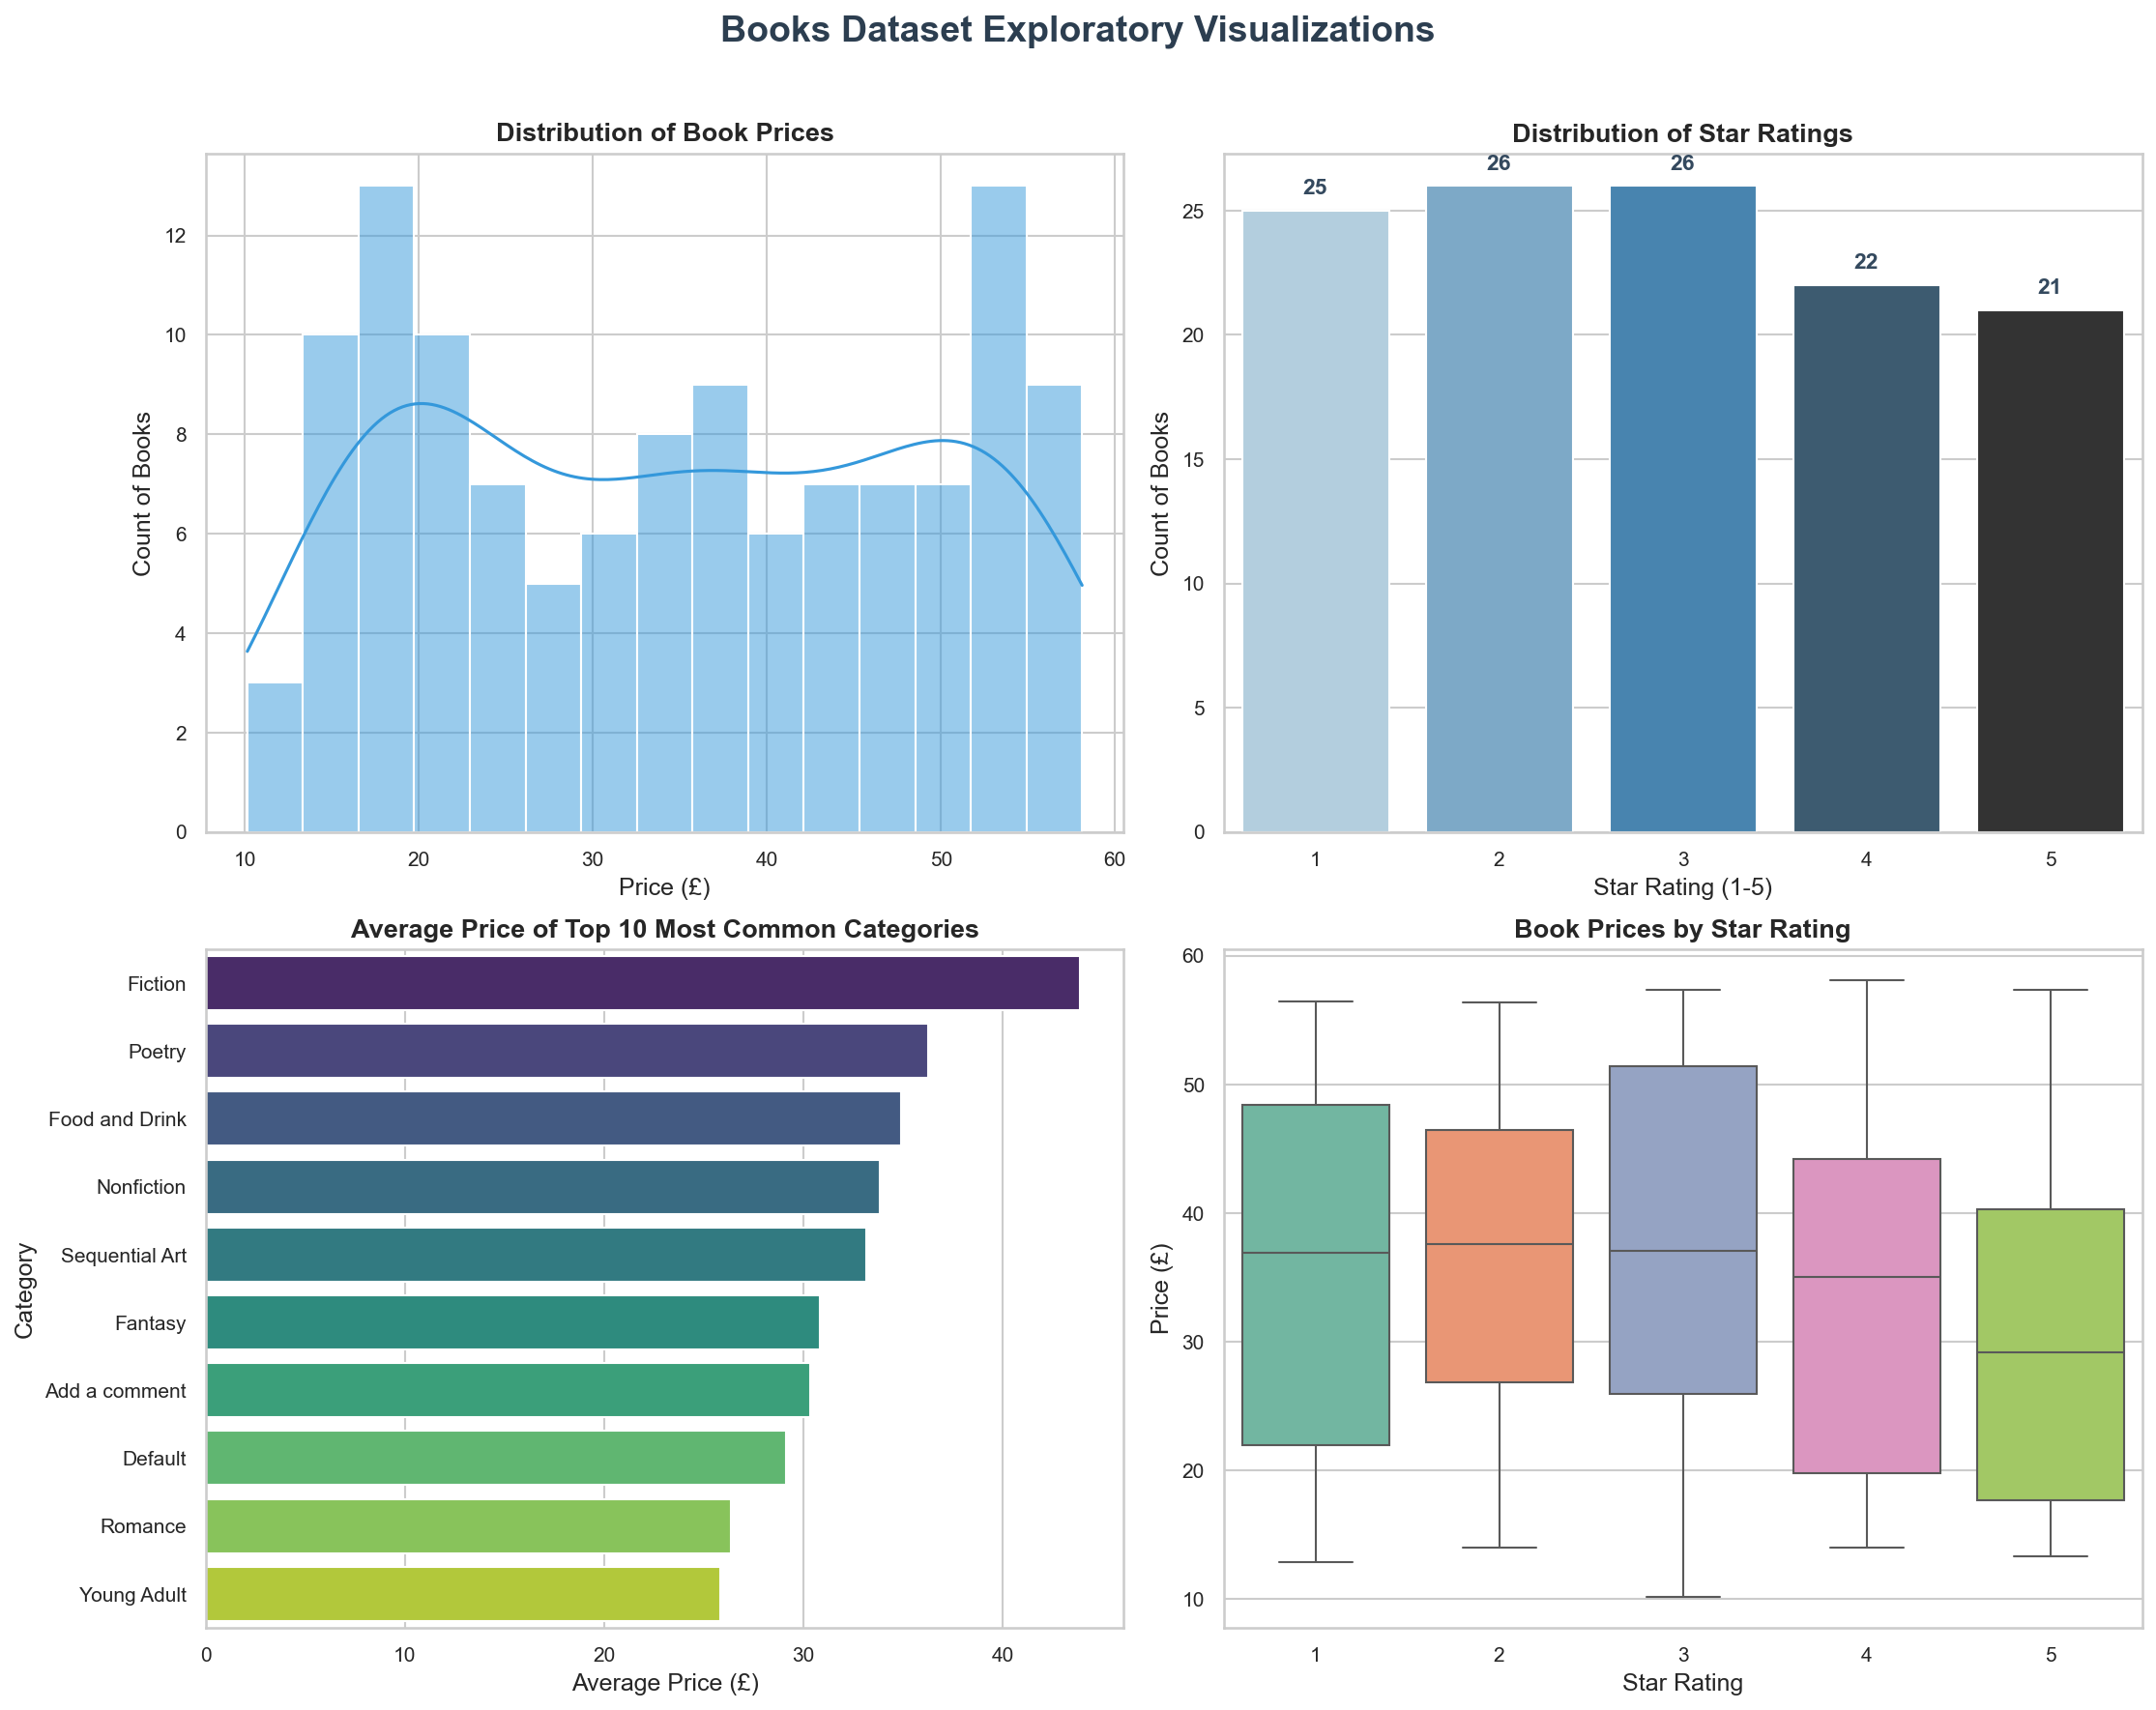

Visualizations grid successfully saved as 'books_eda_plots.png'.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply clean, professional visual themes
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

# Configure a multi-plot layout (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Books Dataset Exploratory Visualizations", fontsize=18, fontweight='bold', color="#2c3e50")

# Plot 1: Price Distribution (Histogram + KDE)
sns.histplot(df_cleaned['price'], kde=True, color="#3498db", ax=axes[0, 0], bins=15)
axes[0, 0].set_title("Distribution of Book Prices", fontweight='semibold')
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Count of Books")

# Plot 2: Rating Distribution (Bar Plot)
rating_counts = df_cleaned['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette="Blues_d", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Star Ratings", fontweight='semibold')
axes[0, 1].set_xlabel("Star Rating (1-5)")
axes[0, 1].set_ylabel("Count of Books")
# Add labels on top of the bars
for idx, count in enumerate(rating_counts.values):
    axes[0, 1].text(idx, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold', color='#34495e')

# Plot 3: Average Price by Category (Top Categories to keep readable)
# We group by category, compute mean price, and select the top 10 most represented categories
top_categories = df_cleaned['category'].value_counts().head(10).index
category_price_df = df_cleaned[df_cleaned['category'].isin(top_categories)]
avg_prices = category_price_df.groupby('category')['price'].mean().sort_values(ascending=False)

sns.barplot(x=avg_prices.values, y=avg_prices.index, hue=avg_prices.index, palette="viridis", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Average Price of Top 10 Most Common Categories", fontweight='semibold')
axes[1, 0].set_xlabel("Average Price (£)")
axes[1, 0].set_ylabel("Category")

# Plot 4: Relationship Plot (Price vs Rating - Box Plot)
sns.boxplot(x='rating', y='price', hue='rating', data=df_cleaned, palette="Set2", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Book Prices by Star Rating", fontweight='semibold')
axes[1, 1].set_xlabel("Star Rating")
axes[1, 1].set_ylabel("Price (£)")

# Tighten formatting and save the visual grid
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig("books_eda_plots.png", dpi=300, bbox_inches='tight')
plt.show()
print("Visualizations grid successfully saved as 'books_eda_plots.png'.")

### Word Cloud from Book Descriptions
Now we generate a high-resolution word cloud from all collected book descriptions, filtering out common english stopwords as well as generic/redundant terms.

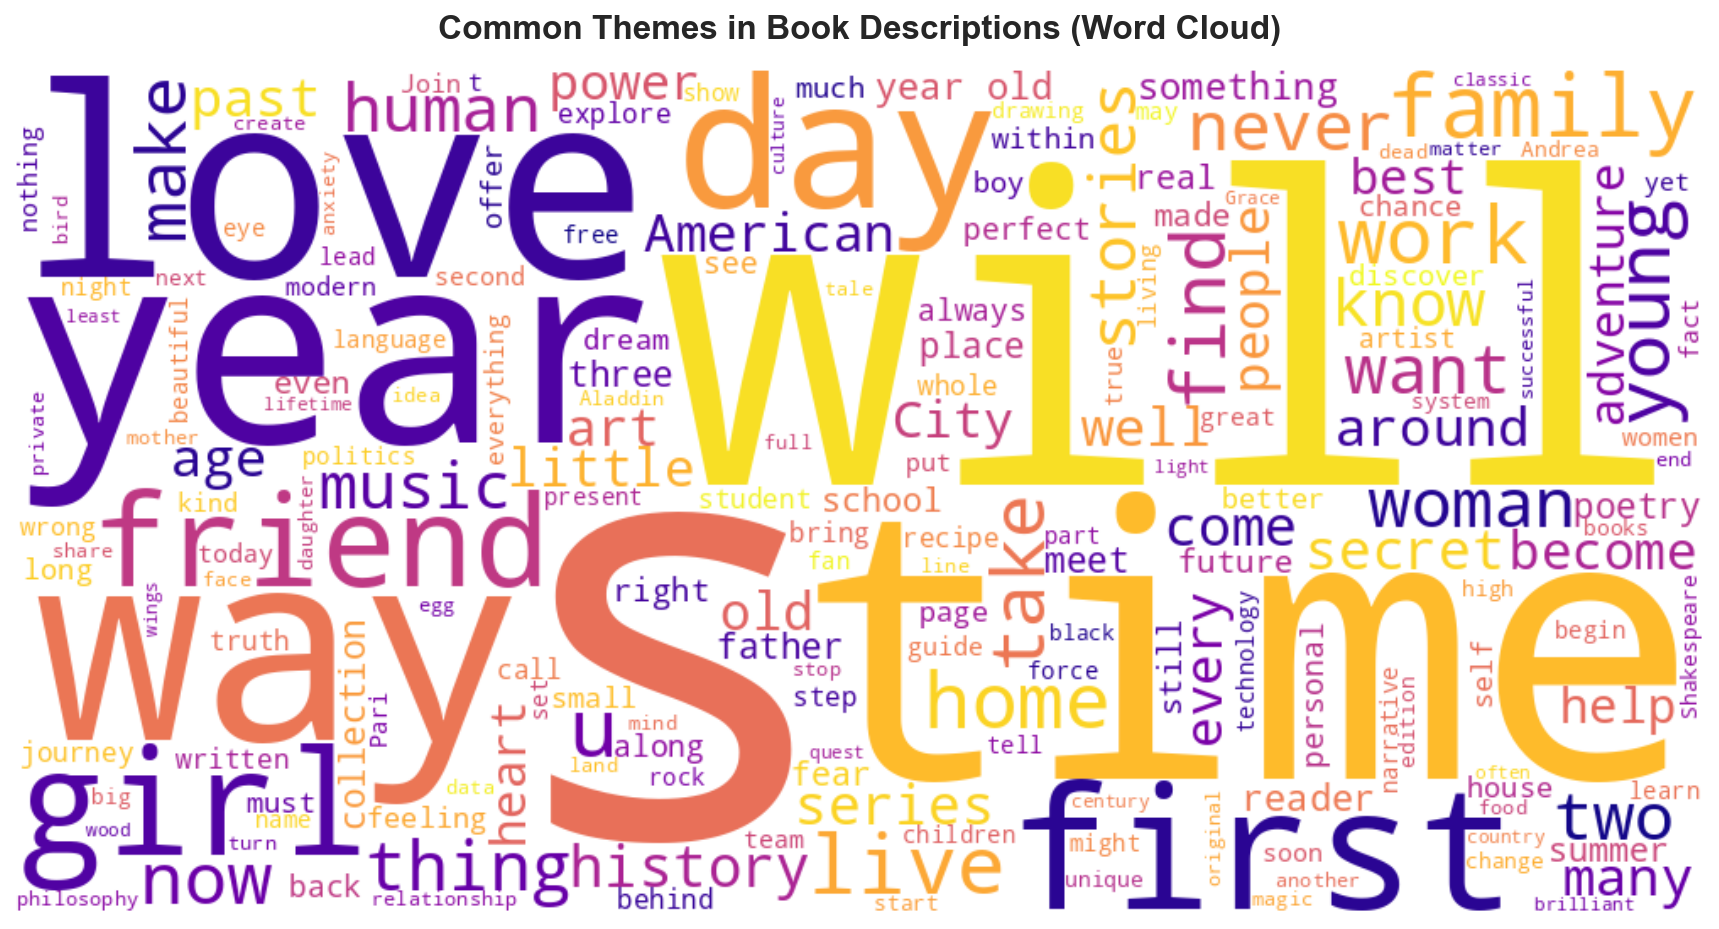

Word cloud visualization saved as 'descriptions_wordcloud.png'.


In [6]:
from wordcloud import WordCloud, STOPWORDS

# Combine all product descriptions
combined_descriptions = " ".join(df_cleaned['product_description'].dropna())

# Create stopwords set and filter generic story terms
stop_words = set(STOPWORDS)
stop_words.update(["book", "story", "novel", "author", "read", "one", "new", "life", "character", "world"])

# Generate the WordCloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words,
    colormap='plasma',
    max_words=200
).generate(combined_descriptions)

# Render the plot
plt.figure(figsize=(12, 6), dpi=150)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Common Themes in Book Descriptions (Word Cloud)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout(pad=0)

# Save as image in the current directory
plt.savefig("descriptions_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()
print("Word cloud visualization saved as 'descriptions_wordcloud.png'.")

### Statistical Analysis and Diagnostics
Let's review the summary statistics and identify patterns across categories, ratings, prices, and engineered features. You can use these numbers directly to support your insights in Task 4.

In [7]:
print("=== Descriptive Statistics for Numerical Data ===")
display(df_cleaned.describe())

print("\n=== Categorical Distribution (Representation counts) ===")
category_counts = df_cleaned['category'].value_counts()
print(f"Total Unique Categories represented: {len(category_counts)}")
print("Top 10 categories:")
print(category_counts.head(10))

print("\n=== Average Price and Rating by Category (Top Categories) ===")
category_stats = df_cleaned.groupby('category').agg(
    average_price=('price', 'mean'),
    average_rating=('rating', 'mean'),
    book_count=('price', 'count')
).sort_values(by='book_count', ascending=False).head(10)
display(category_stats)

print("\n=== Top 5 Best Value Books (Highest Value Score = Rating / Price) ===")
display(df_cleaned.sort_values(by='value_score', ascending=False)[['title', 'category', 'price', 'rating', 'value_score']].head(5))

print("\n=== Recommended Books Preview (Rating >= 4 and Price < Median Price) ===")
recommended_subset = df_cleaned[df_cleaned['recommended'] == True]
print(f"Total Recommended Books found: {len(recommended_subset)}")
display(recommended_subset.sort_values(by='value_score', ascending=False)[['title', 'category', 'price', 'rating', 'value_score']].head(5))

=== Descriptive Statistics for Numerical Data ===


,price,rating,number_of_reviews,stock,description_word_count,value_score
count,120.000000,120.000000,120.0,120.000000,120.000000,120.000000
mean,34.848167,2.900000,0.0,16.983333,225.575000,0.105309
std,14.319930,1.392658,0.0,1.420045,101.126983,0.081725
min,10.160000,1.000000,0.0,16.000000,36.000000,0.017700
25%,21.635000,2.000000,0.0,16.000000,165.750000,0.050850
50%,34.775000,3.000000,0.0,16.000000,213.000000,0.076750
75%,47.967500,4.000000,0.0,18.000000,271.750000,0.140850
max,58.110000,5.000000,0.0,22.000000,722.000000,0.374800



=== Categorical Distribution (Representation counts) ===
Total Unique Categories represented: 30
Top 10 categories:
category
Sequential Art    21
Nonfiction        14
Default           10
Poetry             7
Fantasy            6
Young Adult        5
Food and Drink     5
Romance            5
Fiction            5
Add a comment      5
Name: count, dtype: int64

=== Average Price and Rating by Category (Top Categories) ===


,average_price,average_rating,book_count
category,,,
Sequential Art,33.157619,2.904762,21
Nonfiction,33.805714,3.142857,14
Default,29.109000,2.900000,10
Poetry,36.238571,2.571429,7
Fantasy,30.820000,3.000000,6
Fiction,43.872000,3.800000,5
Romance,26.340000,3.200000,5
Food and Drink,34.886000,2.200000,5
Add a comment,30.342000,2.600000,5



=== Top 5 Best Value Books (Highest Value Score = Rating / Price) ===


,title,category,price,rating,value_score
89,Princess Between Worlds (Wide-Awake Princess #5),Fantasy,13.34,5,0.3748
90,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",Sequential Art,13.61,5,0.3674
36,Sophie's World,Philosophy,15.94,5,0.3137
81,Patience,Sequential Art,10.16,3,0.2953
55,Thirst,Fiction,17.27,5,0.2895



=== Recommended Books Preview (Rating >= 4 and Price < Median Price) ===
Total Recommended Books found: 24


,title,category,price,rating,value_score
89,Princess Between Worlds (Wide-Awake Princess #5),Fantasy,13.34,5,0.3748
90,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",Sequential Art,13.61,5,0.3674
36,Sophie's World,Philosophy,15.94,5,0.3137
55,Thirst,Fiction,17.27,5,0.2895
8,Set Me Free,Young Adult,17.46,5,0.2864
